## In-depth energy module behaviour (Procedural)

In this notebook, we set up a graph with a single edge to demonstrate some basic functionality of the Energy module by directly using procedural functions and simple data structures.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
import shapely.geometry
from shapely.geometry import Point
import pathlib
import simpy

# package(s) related to the simulation
import datetime
import opentnsim
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.energy import ConsumesEnergy
from opentnsim.core.utils import create_object
from opentnsim.energy.calculations import (
    sample_engine_age, 
    calculate_properties, 
    calculate_total_resistance, 
    calculate_total_power_required, 
    calculate_wave_resistance,
    calculate_viscous_resistance,
    calculate_frictional_resistance,
    calculate_appendage_resistance,
    calculate_residual_resistance,
    karpov
)

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd

# package(s) needed for plotting
import matplotlib.pyplot as plt

print(f"This notebook is executed with OpenTNSim version {opentnsim.__version__}")

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 0. Create environment
We do not need an environment for this case.

#### 1. Create graph

We do need a graph. In this case, we create a single edge of exactly 100 km.

In [2]:
geod = Geod(ellps="WGS84")
lon0, lat0 = 0, 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000)

coords = {"0": (lon0, lat0), "1": (lon1, lat1)}
FG = nx.DiGraph()
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))
FG.add_edge("0", "1", weight=1, Info={'GeneralDepth': 10})
FG.add_edge("1", "0", weight=1, Info={'GeneralDepth': 10})

#### 2.Create vessel

Instead of a `Vessel` class, we use a dictionary (`vessel_data`) to store and pass the vessel's state and properties to the simulation.

In [3]:
def create_vessel_data(**kwargs):
    """Creates a dictionary to hold all vessel properties and states."""
    vessel_data = {
        # TODO: Check why we need all these properties.  Some seem to be unrelated to vessels (e.g. g, rho)
        'nu': 1 * 10 ** (-6),
        'rho': 1000,
        'g': 9.81,
        'x': 2,
        'D_s': 1.4,
        'eta_o': 0.4,
        'eta_r': 1.00,
        'eta_t': 0.98,
        'eta_g': 0.96,
        'c_stern': 0,
        'C_BB': 0.2,
        'C_B': 0.85,
        'one_k2': 2.5,
        'current_year': 2024,
        'L': 100,
        'B': 20,
        'T': 7,
        'bulbous_bow': True,
        'P_installed': 5000,
        'P_hotel_perc': 0.05,
        'karpov_correction': True,
        'L_w': 3,
    }
    vessel_data.update(kwargs)
    
    vessel_data['P_hotel'] = vessel_data['P_hotel_perc'] * vessel_data['P_installed']
        
    age = sample_engine_age(vessel_data['L_w'])
    vessel_data['C_year'] = vessel_data['current_year'] - age
        
    props = calculate_properties(
        C_B=vessel_data['C_B'], L=vessel_data['L'], B=vessel_data['B'], T=vessel_data['T'],
        bulbous_bow=vessel_data['bulbous_bow'], C_BB=vessel_data['C_BB']
    )
    
    vessel_data.update(props._asdict())
    return vessel_data

#### 3. Run Calculation
We define a simulation function, and run the vessel per category below:

In [4]:
def run_calculation(vessel_params, v, distance, h_0):
    """Runs a single calculation for a given velocity and returns a results dictionary."""
    vessel_data = create_vessel_data(**vessel_params, v=v)
    vessel_data['h_0'] = h_0
    V_2 = karpov(**vessel_data)[1]
    vessel_data['V_2'] = V_2
    F_rL, *_, R_W = calculate_wave_resistance(**vessel_data)
    vessel_data['R_W'] = R_W
    R_f, C_f = calculate_frictional_resistance(**vessel_data)[:2]
    vessel_data['R_f'] = R_f
    vessel_data['C_f'] = C_f
    R_f_one_k1 = calculate_viscous_resistance(**vessel_data)[-1]
    R_APP = calculate_appendage_resistance(**vessel_data)
    R_tot = calculate_total_resistance(**vessel_data)
    vessel_data['R_f_one_k1'] = R_f_one_k1
    vessel_data['R_APP'] = R_APP
    vessel_data['F_rL'] = F_rL
    vessel_data['R_tot'] = R_tot
    P_tot = calculate_total_power_required(**vessel_data)[-2]
    vessel_data['P_tot'] = P_tot
    R_res = calculate_residual_resistance(**vessel_data)[-1]
    vessel_data['R_res'] = R_res
    
    duration = distance / v
    total_energy = vessel_data['P_tot'] * duration / 3600  # kWh
    
    # Prepare results
    result = {
        'v': v,
        'P_tot': vessel_data['P_tot'],
        'total_energy': total_energy,
        'R_tot': vessel_data['R_tot'],
        'R_f_one_k1': vessel_data['R_f_one_k1'],
        'R_APP': vessel_data['R_APP'],
        'R_W': vessel_data['R_W'],
        'R_res': vessel_data['R_res']
    }
    return result

##### 3.1 The effects of vessel velocity on resistance, power and energy

We run the calculation for a range of velocities.

In [5]:
vessel_params = {
    'L': 135, 'B': 11.75, 'T': 2.75,
    'P_installed': 1750, 'L_w': 3, 'C_year': 1990,
    'karpov_correction': True, 'bulbous_bow': False,
    'P_hotel_perc': 0.05
}

velocity_range = np.arange(0.1, 6.0, 0.1)
results = []

distance_m = 100000
water_depth_m = 10

for v_set in velocity_range:
    result = run_calculation(vessel_params, v_set, distance_m, water_depth_m)
    results.append(result)

results_df = pd.DataFrame(results)

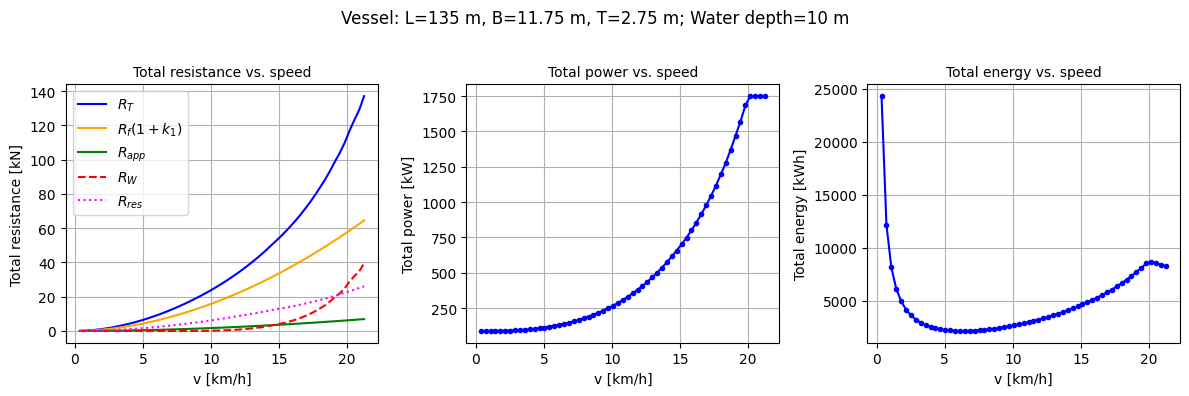

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot resistance components
axes[0].plot(results_df['v'] * 3.6, results_df['R_tot'], '-', c='blue', label='$R_T$')
axes[0].plot(results_df['v'] * 3.6, results_df['R_f_one_k1'], '-', c='orange', label='$R_f (1+k_1)$')
axes[0].plot(results_df['v'] * 3.6, results_df['R_APP'], '-', c='green', label='$R_{app}$')
axes[0].plot(results_df['v'] * 3.6, results_df['R_W'], '--', c='red', label='$R_W$')
axes[0].plot(results_df['v'] * 3.6, results_df['R_res'], ':', c='magenta', label='$R_{res}$')
axes[0].set_xlabel('v [km/h]')
axes[0].set_ylabel('Total resistance [kN]')
axes[0].set_title('Total resistance vs. speed', fontsize=10)
axes[0].legend(loc='upper left')
axes[0].grid(True)

# Plot total power
axes[1].plot(results_df['v'] * 3.6, results_df['P_tot'], '-o', c='blue', markersize=3)
axes[1].set_xlabel('v [km/h]')
axes[1].set_ylabel('Total power [kW]')
axes[1].set_title('Total power vs. speed', fontsize=10)
axes[1].grid(True)

# Plot total energy
axes[2].plot(results_df['v'] * 3.6, results_df['total_energy'], '-o', c='blue', markersize=3)
axes[2].set_xlabel('v [km/h]')
axes[2].set_ylabel('Total energy [kWh]')
axes[2].set_title('Total energy vs. speed', fontsize=10)
axes[2].grid(True)

fig.suptitle(f"Vessel: L={vessel_params['L']} m, B={vessel_params['B']} m, T={vessel_params['T']} m; Water depth={water_depth_m} m", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Panel 1 in the figure above corresponds to Part IV - Figure 5.4 in Van Koningsveld et al (2023), https://doi.org/10.5074/T.2021.004. Panel 2 shows how the R_tot from Panel 1 is converted to P_tot, multiplying with v and using various efficiency factors. Panel 3 shows the total energy that is required to pass the 100 km long edge. This total energy is derived by multiplying the P_tot with the time it takes to pass the edge. For very low v's the R_tot is low, but it also takes long to pass the edge. For high v's the R_tot escalates, but the time to pass the edge reduces.